# CIFAR-10 — analysis & experiments

Thin notebook: all logic lives in `vision_pipeline/`, shared with the
[ImageNet notebook](image_net_analysis.ipynb). The dataset is chosen by `cfg.data.dataset`.

| module | contents |
|---|---|
| `config.py` | config dataclasses, `Config.preset("cifar10"\|"imagenet")`, `set_seed`, `get_device` |
| `data/cifar10.py`, `data/imagenet.py` | one file per dataset: transforms + dataset construction |
| `data/__init__.py` | dataset registry, `Loaders`, `build_loaders` |
| `models/resnet.py` | blocks + `ResNet` with a switchable stem (`cifar` / `imagenet`) |
| `models/cnn.py` | `CNN` — the v1.0 plain conv baseline |
| `models/__init__.py` | `build_model` registry |
| `train.py` | optimizer/scheduler/criterion, `check_accuracy`, `confusion_matrix`, `train`, `setup` |
| `inference.py` | `Predictor`, `evaluate_checkpoint`, TorchScript/ONNX export |
| `cli.py` | `python -m vision_pipeline.cli train\|eval\|predict --dataset cifar10` |

100-epoch runs are ~7 min on an RTX 5080 so they're fine inline, but the CLI is
safer for long jobs (a notebook kernel leaks DataLoader workers on interrupt):

```bash
python -m vision_pipeline.cli train --dataset cifar10 --arch resnet18 --epochs 100
```

In [10]:
%load_ext autoreload
%autoreload 2

from dataclasses import replace

import matplotlib.pyplot as plt
import torch

from vision_pipeline import (
    Config, DataConfig, ModelConfig, TrainConfig,
    Predictor, build_loaders, build_model, check_accuracy, confusion_matrix,
    count_parameters, evaluate_checkpoint, get_device, normalization, set_seed,
    setup, top1, train,
)

device = get_device()
print(device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cuda NVIDIA GeForce RTX 5080


## 1. Configure

`Config.preset("cifar10")` is the v2.0 SGD recipe — the best verified run here (95.61%). ImageNet uses AdamW; SGD only wins on CIFAR-10.
Override anything below.

In [11]:
cfg = Config.preset("cifar10")

# Tweak from here, e.g.:
cfg = replace(cfg, train=replace(cfg.train, epochs=20, lr=0.05, optimizer='adamw'))
# cfg = replace(cfg, data=replace(cfg.data, random_erasing_p=0.0))
cfg

Config(data=DataConfig(dataset='cifar10', root='dataset/', download=True, image_size=32, batch_size=128, eval_batch_size=256, hflip_p=0.5, random_erasing_p=0.5, crop_padding=4, crop_padding_mode='reflect', crop_scale=(0.08, 1.0), crop_ratio=(0.75, 1.3333333333333333), resize_size=256, eval_train_size=10000, eval_samples_per_class=10, num_workers=8, eval_num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2, seed=42), model=ModelConfig(arch='resnet18', num_classes=10, input_channels=3, stem='cifar', layers=None, block='basic', zero_init_residual=True, image_size=32, widths=(16, 32, 64, 64), dropout=(0.0, 0.2, 0.3, 0.0), hidden_dim=128, batch_norm=False, channels_last=True, compile=False), train=TrainConfig(epochs=20, optimizer='adamw', lr=0.05, weight_decay=0.0005, momentum=0.9, nesterov=True, label_smoothing=0.1, scheduler='warmup_cosine', warmup_epochs=5, warmup_start_factor=0.1, eta_min=0.0, amp=True, grad_clip=None, log_every=50, run_dir='runs', checkpoint_dir='

## 2. Data

In [12]:
set_seed(cfg.data.seed)
loaders = build_loaders(cfg.data)
print(loaders.summary())

Training images:          50,000
Held-out images:          10,000
Evaluation subset images: 10,000
Number of classes:        10


In [13]:
images, targets = next(iter(loaders.train))
print("Image batch:", images.shape, images.dtype)
print("Target batch:", targets.shape, targets.dtype)
print("Target range:", targets.min().item(), targets.max().item())

Image batch: torch.Size([128, 3, 32, 32]) torch.float32
Target batch: torch.Size([128]) torch.int64
Target range: 0 9


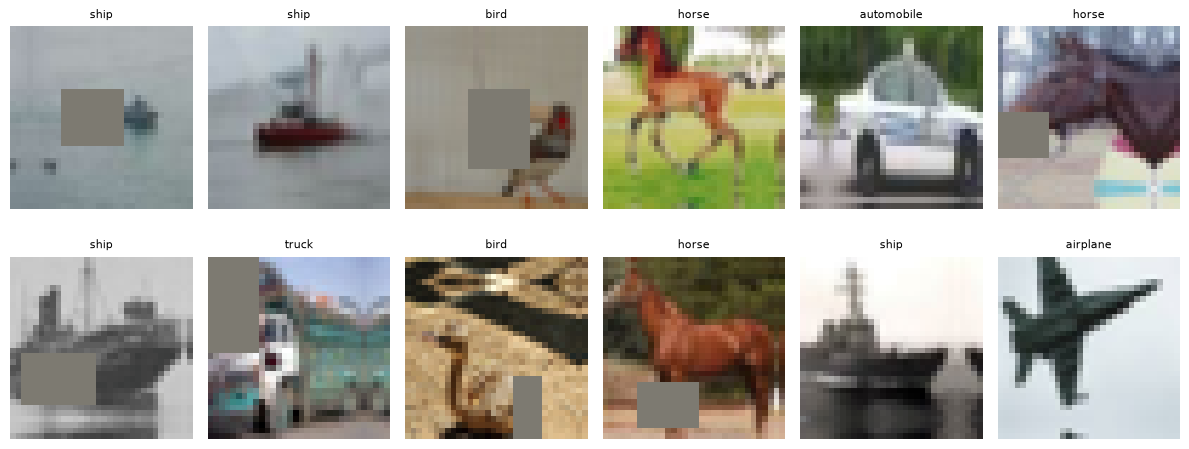

In [14]:
# Visualise the augmented batch (un-normalize first) — the fastest way to catch
# a broken transform pipeline. `normalization()` returns the dataset's mean/std.
mean_t, std_t = (torch.tensor(v).view(3, 1, 1) for v in normalization(cfg.data))

fig, axes = plt.subplots(2, 6, figsize=(12, 5))
for ax, img, target in zip(axes.ravel(), images, targets):
    ax.imshow((img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy())
    ax.set_title(loaders.classes[target], fontsize=8)
    ax.axis("off")
fig.tight_layout()

## 3. Model

In [15]:
set_seed(cfg.train.seed)  # seed right before weight init so the run is reproducible
torch.backends.cudnn.benchmark = True  # fixed input size -> let cudnn pick fastest kernels

net = build_model(cfg.model, device=device)
print(f"{count_parameters(net) / 1e6:.2f}M parameters")

11.17M parameters


In [16]:
# Forward pass on the real batch — catches stem/head shape mistakes early.
batch = images.to(device, non_blocking=True).contiguous(memory_format=torch.channels_last)
net.eval()
with torch.inference_mode():
    logits = net(batch)

print("Output:", logits.shape)
assert logits.shape == (batch.size(0), cfg.model.num_classes)

Output: torch.Size([128, 10])


In [17]:
# Compare architectures cheaply — parameter counts only, no data needed.
# cfg.model.stem stays fixed, so every variant is sized for this dataset.
for arch in ['cnn', 'resnet18', 'resnet34', 'resnet50']:
    m = build_model(replace(cfg.model, arch=arch))
    print(f"{arch:>10}: {count_parameters(m) / 1e6:6.2f}M")
del m

       cnn:   0.19M
  resnet18:  11.17M
  resnet34:  21.28M
  resnet50:  23.52M


## 4. Train

`train()` returns a `History` with per-epoch curves (including `gap`,
train − held-out, the overfitting readout).

In [18]:
probe_cfg = replace(cfg, train=replace(cfg.train, epochs=2, warmup_epochs=1, run_name="probe"))

history = train(net, loaders, cfg, device=device)
history.to_frame()

2026-08-10 14:54:37.488240: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-10 14:54:37.542013: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-10 14:54:38.683285: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-10 14:54:38.685173: I external/local_xla/xla/tsl/cuda/

Epoch [1/20], Loss: 1.7059, Train Acc: 0.5362, Test Acc: 0.5297, LR: 0.014000, 5.5s
Epoch [2/20], Loss: 1.4011, Train Acc: 0.5985, Test Acc: 0.5925, LR: 0.023000, 3.7s
Epoch [3/20], Loss: 1.2306, Train Acc: 0.7608, Test Acc: 0.7488, LR: 0.032000, 3.7s
Epoch [4/20], Loss: 1.1243, Train Acc: 0.7993, Test Acc: 0.7802, LR: 0.041000, 3.6s
Epoch [5/20], Loss: 1.0580, Train Acc: 0.7630, Test Acc: 0.7462, LR: 0.050000, 3.6s
Epoch [6/20], Loss: 1.0157, Train Acc: 0.8283, Test Acc: 0.8047, LR: 0.049454, 3.6s
Epoch [7/20], Loss: 0.9622, Train Acc: 0.8080, Test Acc: 0.7797, LR: 0.047839, 3.6s
Epoch [8/20], Loss: 0.9182, Train Acc: 0.8619, Test Acc: 0.8395, LR: 0.045225, 3.6s
Epoch [9/20], Loss: 0.8858, Train Acc: 0.8790, Test Acc: 0.8453, LR: 0.041728, 3.6s
Epoch [10/20], Loss: 0.8510, Train Acc: 0.8808, Test Acc: 0.8493, LR: 0.037500, 3.6s
Epoch [11/20], Loss: 0.8155, Train Acc: 0.8978, Test Acc: 0.8657, LR: 0.032725, 3.7s
Epoch [12/20], Loss: 0.7883, Train Acc: 0.9100, Test Acc: 0.8724, LR: 0.02

,epoch,loss,train_acc,test_acc,gap,lr,epoch_time
0,0,1.705916,0.5362,0.5297,0.0065,0.014000,5.534568
1,1,1.401070,0.5985,0.5925,0.0060,0.023000,3.653663
2,2,1.230571,0.7608,0.7488,0.0120,0.032000,3.667957
3,3,1.124347,0.7993,0.7802,0.0191,0.041000,3.627922
4,4,1.057971,0.7630,0.7462,0.0168,0.050000,3.620549
5,5,1.015687,0.8283,0.8047,0.0236,0.049454,3.569965
6,6,0.962189,0.8080,0.7797,0.0283,0.047839,3.558427
7,7,0.918197,0.8619,0.8395,0.0224,0.045225,3.573437
8,8,0.885795,0.8790,0.8453,0.0337,0.041728,3.643257
9,9,0.851023,0.8808,0.8493,0.0315,0.037500,3.621071


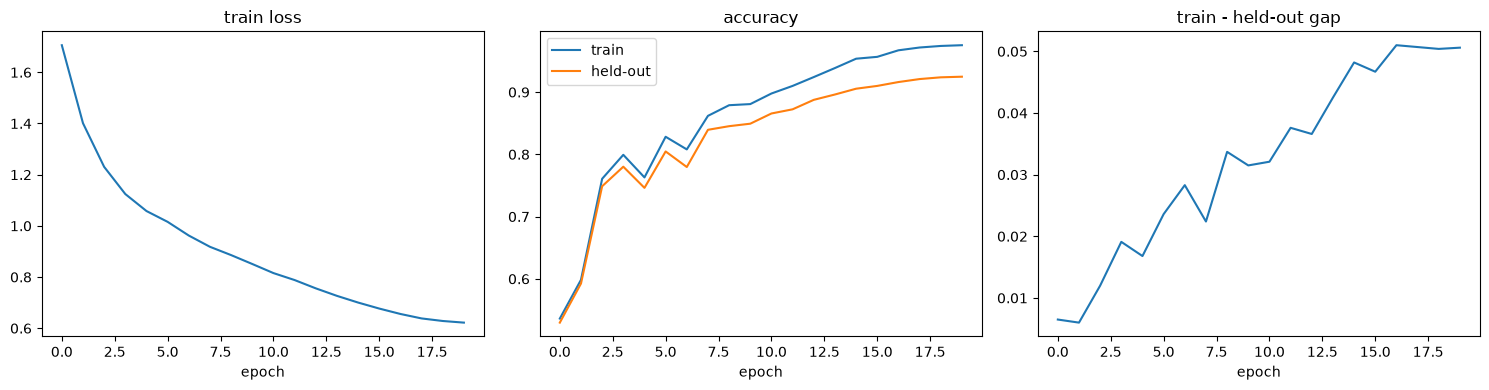

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.epoch, history.loss);                  axes[0].set_title("train loss")
axes[1].plot(history.epoch, history.train_acc, label="train")
axes[1].plot(history.epoch, history.test_acc, label="held-out"); axes[1].legend(); axes[1].set_title("accuracy")
axes[2].plot(history.epoch, history.gap);                   axes[2].set_title("train - held-out gap")
for ax in axes: ax.set_xlabel("epoch")
fig.tight_layout()

### Parameter sweep

Each variant gets a fresh model + its own run directory, so TensorBoard curves
never overlap. Keep `epochs` small — this is for ranking, not final numbers.

In [20]:
# One run per learning rate — everything else held fixed, so the difference in
# the curves is attributable to lr alone. SGD is the preset optimizer here; the
# AdamW entry is the reference point it beat (95.61% vs 94.14%).
sweep = {
    "sgd_0.1":    replace(cfg.train, lr=0.1),
    "sgd_0.05":   replace(cfg.train, lr=0.05),
    "adamw_1e-3": replace(cfg.train, optimizer="adamw", lr=1e-3, weight_decay=1e-2),
}

results = {}
for name, tcfg in sweep.items():
    variant = replace(cfg, train=replace(tcfg, epochs=5, warmup_epochs=1, run_name=f"sweep_{name}"))
    set_seed(variant.train.seed)
    model = build_model(variant.model, device=device)
    results[name] = train(model, loaders, variant, device=device, verbose=False)
    print(f"{name:>12}: best held-out {results[name].best_acc:.4f}")
    del model
    torch.cuda.empty_cache()

     sgd_0.1: best held-out 0.8093
    sgd_0.05: best held-out 0.8206
  adamw_1e-3: best held-out 0.7863


Text(0.5, 1.0, 'sweep')

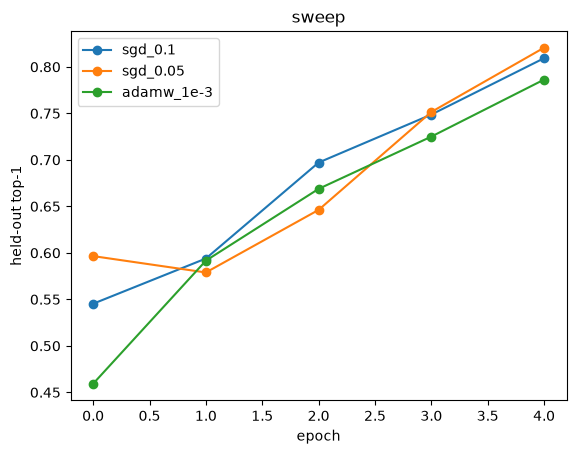

In [21]:
for name, h in results.items():
    plt.plot(h.epoch, h.test_acc, marker="o", label=name)
plt.xlabel("epoch"); plt.ylabel("held-out top-1"); plt.legend(); plt.title("sweep")

In [22]:
# Augmentation sweep — same knob shape, on DataConfig instead.
# for p in [0.0, 0.25, 0.5]:
#     variant = replace(
#         cfg,
#         data=replace(cfg.data, random_erasing_p=p),
#         train=replace(cfg.train, epochs=5, warmup_epochs=1, run_name=f"erasing_{p}"),
#     )
#     set_seed(variant.data.seed)
#     ldrs = build_loaders(variant.data)
#     set_seed(variant.train.seed)
#     m = build_model(variant.model, device=device)
#     h = train(m, ldrs, variant, device=device, verbose=False)
#     print(f"erasing p={p}: best {h.best_acc:.4f}, final gap {h.gap[-1]:.4f}")

### Resume from a checkpoint

`setup()` builds model/loaders/optimizer/scheduler and restores state in one call.

In [23]:
# CKPT = "checkpoints/20260717-143505_resnet34_best.pt"
# model, loaders, optimizer, scheduler, criterion, device, resume_state = setup(
#     cfg, resume=CKPT, fresh_schedule=False,
# )
# history = train(
#     model, loaders, cfg,
#     optimizer=optimizer, scheduler=scheduler, criterion=criterion,
#     device=device, **resume_state,
# )

## 5. Evaluate & inference

In [24]:
print(check_accuracy(loaders.val, net, device=device, topk=(1, 5)))

{1: 0.9248, 5: 0.9968}


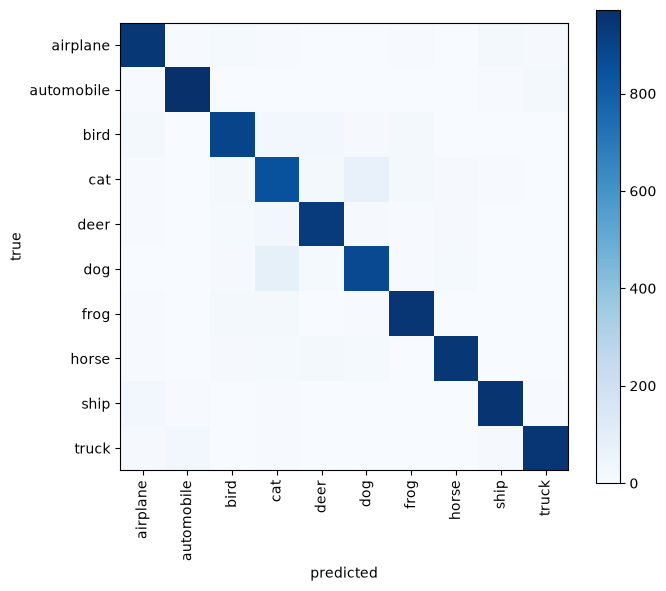

In [25]:
# Where does it actually fail? Rows = true label, cols = prediction.
cm = confusion_matrix(loaders.val, net, num_classes=cfg.model.num_classes, device=device)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(loaders.classes)), loaders.classes, rotation=90)
ax.set_yticks(range(len(loaders.classes)), loaders.classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
fig.colorbar(im)
fig.tight_layout()

In [26]:
# The checkpoint embeds its Config, so the Predictor rebuilds the right
# architecture AND the right eval transform on its own.
# CKPT = "checkpoints/20260717-143505_resnet34_best.pt"
# print(evaluate_checkpoint(CKPT, cfg))
# predictor = Predictor.from_checkpoint(CKPT)
# predictor.predict_paths(["some_image.png"], topk=3)

In [27]:
# Export for serving without the Python model code.
# predictor.export_torchscript("checkpoints/resnet18_cifar.ts")
# predictor.export_onnx("checkpoints/resnet18_cifar.onnx")

## Benchmark

### Goal

CIFAR-10
* SOTA training acc = 94-96%
* Good test acc: 85%+
* Gap = around 5%–10% — no augmentation.
* Gap = 2%–5% — with augmentation, BatchNorm, dropout, and weight decay.

### Fine-tuning results

#### v1.0 — plain CNN (`arch="cnn"`)

    * Flow = input -> conv(16,3,1,1) -> gelu -> maxpool(2,2) -> conv(32,3,1,1) -> gelu
             -> dropout(0.2) -> maxpool(2,2) -> conv(64,3,1,1) -> gelu -> dropout(0.3)
             -> maxpool(2,2) -> conv(64,3,1,1) -> gelu -> Flatten -> Linear(64*4*4, 128)
             -> gelu -> Linear(128, 10) -> (CrossEntropyLoss)
    * Optimiser = AdamW, lr = 1e-3
    * # epoch = 20, batch_size = 64
    * Transform: normalising to [-1, 1]; Noise: 0.03

Result: Train Acc 0.8922, Test Acc 0.7565

#### v1.5 — ResNet-34, ImageNet stem + MLP head

    * ImageNet stem conv(64,7,2,3) + maxpool(3,2,1), 512-256-128-64-10 GELU head
    * AdamW lr=1e-3 wd=1e-2, cosine to 1e-6, 100 epochs, batch_size = 64

Result: Train Acc 0.9251, Test Acc 0.8247 — gap ~10%

#### v2.0 — canonical CIFAR ResNet-18 recipe (2026-07-17) — `Config.preset("cifar10")`

Changes vs v1.5:

    * Stem: conv(64,3,1,1) + BN + ReLU, NO maxpool — the ImageNet stem was shrinking
      32x32 inputs to 8x8 before the first block; stages now see 32-16-8-4 maps
      (this is `ModelConfig.stem = "cifar"` in the merged pipeline)
    * Block: post-add activation relu(identity + residual); bias-free convs;
      BN (not GroupNorm) in the downsample shortcut
    * Head: single Linear(512, 10) instead of the 512-256-128-64-10 GELU MLP
    * Depth: resnet18 [2,2,2,2] instead of resnet34 [3,4,6,3]
    * Init: Kaiming fan-out + zero-init of each block's last BN gamma
    * Data: RandomCrop(reflect) + HFlip -> ToTensor -> Normalize -> RandomErasing(p=0.5);
      removed VerticalFlip, the 2x-1 Lambda, and the in-loop Gaussian input noise
    * Optimiser: SGD lr=0.1, momentum=0.9, nesterov, wd=5e-4 on weights only;
      CrossEntropyLoss(label_smoothing=0.1); no gradient clipping
    * Schedule: 5-epoch linear warmup -> cosine to 0; 100 epochs, batch_size = 128
    * Systems: AMP + channels_last + cudnn.benchmark; seeded (42); per-run TensorBoard dir
    * Eval: train accuracy on a clean fixed 10k subset (was: full augmented train set)

Result (verified, 2026-07-17, RTX 5080, ~3.5 s/epoch, ~6 min total):

    Train Acc 0.9997, Test Acc 0.9561 (best), gap 4.4%
    (loss floors near ~0.52 because of label smoothing 0.1 — expected)

Reproduce with:

    python -m vision_pipeline.cli train --dataset cifar10 --epochs 100

#### v2.1 — same recipe, resnet34 + AdamW (2026-07-17)

    AdamW lr=1e-3, weight_decay=1e-2; everything else as v2.0.
    Train Acc 1.0000, Test Acc 0.9414 (best) — trails the v2.0 SGD run by ~1.5%,
    which is why CIFAR-10 keeps SGD while ImageNet uses AdamW.